**Cell 1 — Imports and configuration**

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = os.getcwd()
GRID_STEP = 0.01

**Cell 2 — Grid and copula surfaces**

In [21]:
x = np.arange(0, 1.01, GRID_STEP)
y = np.arange(0, 1.01, GRID_STEP)
X, Y = np.meshgrid(x, y)

M = np.minimum(X, Y)
W = np.maximum(X + Y - 1, 0)
Pi = X * Y

**Cell 3 — Helper function to style each 3D subplot**

In [22]:
def style_copula_axis(ax, title):
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("white")
    ax.yaxis.pane.set_edgecolor("white")
    ax.zaxis.pane.set_edgecolor("white")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.view_init(elev=25, azim=235)
    ax.set_xticks([0.5])
    ax.set_yticks([0.5])
    ax.set_zticks([0, 0.5, 1])

**Cell 4 — Plot all three surfaces**

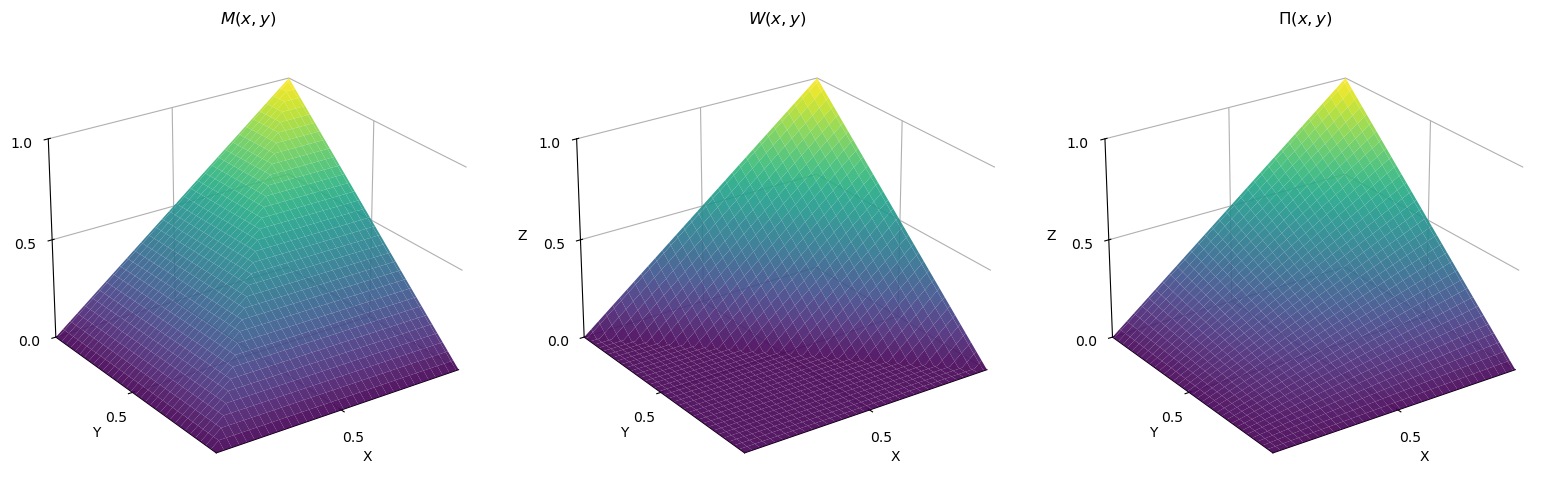

In [23]:
fig = plt.figure(figsize=(16, 5))

titles = [r"$M(x,y)$", r"$W(x,y)$", r"$\Pi(x,y)$"]
surfaces = [M, W, Pi]

for k, (Z, title) in enumerate(zip(surfaces, titles)):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)
    style_copula_axis(ax, title)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "copula_bounds.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()